# CSE754 - PHASE 7
## Fixed Acquisition Function + Active Learning Re-run (fixed crops, both splits)
Author: Sadia Ruhama — MSc Proposal (CSE 754)

**What changed vs. Phase 4 v2, and why.** Phase 2's round-0 acquisition comparison showed plain
**entropy sampling capturing 25% rare-class examples in its top-B, vs. only 10% for
`class_balanced_bald`** — the proposed acquisition function was being beaten by the simplest
baseline. The likely cause: `class_balanced_bald` reweights a candidate by the inverse frequency
of its **predicted (argmax) class** among currently-labeled examples. Early in training the model
rarely predicts the rare class for anything, so the reweighting term almost never activates for
the examples that need it — it's a chicken-and-egg problem.

**The fix (`class_balanced_bald_v2`).** Reweight by the model's **full predicted probability mass
on the rare/under-represented classes**, not just whichever class currently wins the argmax. A
candidate the model is 30% confident is rare (even if its argmax is a common class) now
contributes proportionally, instead of contributing nothing until the model is confident enough
to actually predict "rare".

This notebook:
1. Defines both the old and new acquisition function side-by-side and reruns the **round-0,
   pre-acquisition strategy comparison** (random / entropy / margin / BALD / old class-balanced
   BALD / new class-balanced BALD) so the fix can be judged directly against the Phase 2 baseline
   numbers rather than asserted.
2. Runs the **full active-learning loop** (Phase 4 v2's early-stopping + weight-decay fix, plus
   post-hoc temperature scaling) using the new acquisition function, on Phase 6's fixed-crop data.
3. Runs it **twice** — once on `data_v2/` (same-batch) and once on `data_crossbatch_v2/`
   (cross-batch, held-out wells) — via a single `run_experiment()` function, so the actual
   same-batch vs. cross-batch generalization-gap number the proposal asks for (Slide 31) comes
   out of this notebook directly.

Recommended runtime: Colab GPU (T4 is enough).

## 1. Setup — installs and Google Drive

In [ ]:
!pip install -q -U transformers peft accelerate torchao scikit-learn matplotlib timm

import os, json, random, time
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, average_precision_score, balanced_accuracy_score

from transformers import AutoImageProcessor, AutoModel
from peft import LoraConfig, get_peft_model

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
CKPT_DIR = os.path.join(OUT_DIR, 'checkpoints')
DATA_DIR_SAMEBATCH = os.path.join(PROJECT_ROOT, 'data_v2')
DATA_DIR_CROSSBATCH = os.path.join(PROJECT_ROOT, 'data_crossbatch_v2')
for d in [OUT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive
Using device: cuda


## 2. Config
`num_classes=8`, `rare_class_idx=2` (BV2) carried over from Phase 6's printed mapping — same
class names, same sorted order, so both `data_v2/` and `data_crossbatch_v2/` use this mapping.

In [ ]:
@dataclass
class Config:
    image_size: int = 224
    num_classes: int = 8
    rare_class_idx: int = 2   # BV2, per Phase 6's printed class-index mapping

    backbone_name: str = 'facebook/dinov2-small'
    lora_r: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.05
    lora_target_modules: Tuple[str, ...] = ('query', 'value')

    hidden_dim: int = 256
    mc_dropout_p: float = 0.3
    mc_passes: int = 20

    n_al_rounds: int = 8
    acquisition_batch_size: int = 20
    class_balance_power: float = 1.0
    n_seed_labeled: int = 80

    lr_head: float = 1e-3
    lr_lora: float = 1e-4
    weight_decay: float = 3e-3          # carried over from Phase 4 v2's overfitting fix
    epochs_per_round: int = 15          # upper bound; early stopping decides real length
    batch_size: int = 32
    focal_gamma: float = 2.0

    early_stop_patience: int = 3
    early_stop_min_delta: float = 1e-4

    seed: int = 42

cfg = Config()
print(cfg)

Config(image_size=224, num_classes=8, rare_class_idx=2, backbone_name='facebook/dinov2-small', lora_r=8, lora_alpha=16, lora_dropout=0.05, lora_target_modules=('query', 'value'), hidden_dim=256, mc_dropout_p=0.3, mc_passes=20, n_al_rounds=8, acquisition_batch_size=20, class_balance_power=1.0, n_seed_labeled=80, lr_head=0.001, lr_lora=0.0001, weight_decay=0.003, epochs_per_round=15, batch_size=32, focal_gamma=2.0, early_stop_patience=3, early_stop_min_delta=0.0001, seed=42)


## 3. Backbone, Bayesian head, loss, data loading helpers (unchanged from Phase 4 v2)

In [ ]:
processor = AutoImageProcessor.from_pretrained(cfg.backbone_name)

def build_backbone(cfg: Config):
    backbone = AutoModel.from_pretrained(cfg.backbone_name)
    for p in backbone.parameters():
        p.requires_grad = False
    lora_config = LoraConfig(r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout,
                              target_modules=list(cfg.lora_target_modules), bias='none')
    return get_peft_model(backbone, lora_config)


class AlwaysOnDropout(nn.Dropout):
    def forward(self, x):
        return F.dropout(x, p=self.p, training=True)


class BayesianHead(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_classes, p):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), AlwaysOnDropout(p),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(), AlwaysOnDropout(p),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, embeddings):
        return self.net(embeddings)


class RareCellModel(nn.Module):
    def __init__(self, backbone, cfg: Config):
        super().__init__()
        self.backbone = backbone
        embed_dim = backbone.config.hidden_size
        self.head = BayesianHead(embed_dim, cfg.hidden_dim, cfg.num_classes, cfg.mc_dropout_p)
    def embed(self, pixel_values):
        return self.backbone(pixel_values=pixel_values).last_hidden_state[:, 0, :]
    def forward(self, pixel_values):
        return self.head(self.embed(pixel_values))


def class_balanced_focal_loss(logits, targets, class_counts, gamma=2.0, beta=0.999, eps=1e-8):
    num_classes = logits.shape[1]
    effective_num = 1.0 - np.power(beta, class_counts)
    weights = (1.0 - beta) / np.clip(effective_num, eps, None)
    weights = weights / weights.sum() * num_classes
    weights = torch.tensor(weights, dtype=torch.float32, device=logits.device)
    log_probs = F.log_softmax(logits, dim=1)
    probs = log_probs.exp()
    ce = F.nll_loss(log_probs, targets, weight=weights, reduction='none')
    pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    focal_term = (1 - pt).clamp(min=eps) ** gamma
    return (focal_term * ce).mean()


class HFProcessorWrapper:
    def __init__(self, processor): self.processor = processor
    def __call__(self, pil_img):
        return self.processor(images=pil_img, return_tensors='pt')['pixel_values'][0]

def build_real_datasets(data_dir, processor):
    tfm = HFProcessorWrapper(processor)
    train_pool = ImageFolder(os.path.join(data_dir, 'train'), transform=tfm)
    val_set = ImageFolder(os.path.join(data_dir, 'val'), transform=tfm)
    test_set = ImageFolder(os.path.join(data_dir, 'test'), transform=tfm)
    return train_pool, val_set, test_set

def make_loader(dataset, indices, batch_size, shuffle):
    return DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=shuffle,
                       num_workers=2, drop_last=False)

def get_labels(dataset, indices):
    return np.array(dataset.targets)[indices]

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

## 4. MC-Dropout + acquisition functions — OLD and NEW class-balanced BALD side by side
`class_balanced_bald` (Phase 2/4's original) reweights by the inverse frequency of each
candidate's **argmax predicted class**. `class_balanced_bald_v2` reweights by the inverse
frequency dotted with the **full predicted probability vector**, so partial belief in an
under-represented class still contributes to the score even before the model is confident enough
to make that its top prediction.

In [ ]:
@torch.no_grad()
def mc_dropout_predict(model, loader, T, device):
    model.eval()
    all_probs = []
    for t in range(T):
        batch_probs = []
        for pixel_values, _ in loader:
            pixel_values = pixel_values.to(device)
            probs = F.softmax(model(pixel_values), dim=1)
            batch_probs.append(probs.cpu().numpy())
        all_probs.append(np.concatenate(batch_probs, axis=0))
    return np.stack(all_probs, axis=0)


def bald_scores(mc_probs):
    eps = 1e-12
    mean_probs = mc_probs.mean(axis=0)
    predictive_entropy = -(mean_probs * np.log(mean_probs + eps)).sum(axis=1)
    per_pass_entropy = -(mc_probs * np.log(mc_probs + eps)).sum(axis=2)
    return predictive_entropy - per_pass_entropy.mean(axis=0)


def entropy_scores(mc_probs):
    mean_probs = mc_probs.mean(axis=0)
    eps = 1e-12
    return -(mean_probs * np.log(mean_probs + eps)).sum(axis=1)


def margin_scores(mc_probs):
    mean_probs = mc_probs.mean(axis=0)
    sorted_probs = np.sort(mean_probs, axis=1)
    return -(sorted_probs[:, -1] - sorted_probs[:, -2])


def class_balanced_bald(mc_probs, labeled_class_counts, power=1.0):
    '''ORIGINAL (Phase 2/4): reweights by inverse frequency of the PREDICTED
    (argmax) class only -- can fail to help exactly the rare classes it's meant
    to surface, before the model is confident enough to predict them.'''
    scores = bald_scores(mc_probs)
    mean_probs = mc_probs.mean(axis=0)
    pred_class = mean_probs.argmax(axis=1)
    counts = labeled_class_counts.astype(np.float64) + 1.0
    inv_freq = (1.0 / counts) ** power
    inv_freq = inv_freq / inv_freq.sum() * len(counts)
    return scores * inv_freq[pred_class]


def class_balanced_bald_v2(mc_probs, labeled_class_counts, power=1.0):
    '''FIXED: reweights by the FULL predicted probability distribution dotted
    with inverse-frequency weights, so partial belief in an under-represented
    class contributes to the score even when it isn't the argmax yet.'''
    scores = bald_scores(mc_probs)
    mean_probs = mc_probs.mean(axis=0)          # (N, C)
    counts = labeled_class_counts.astype(np.float64) + 1.0
    inv_freq = (1.0 / counts) ** power
    inv_freq = inv_freq / inv_freq.sum() * len(counts)
    weights = (mean_probs * inv_freq[None, :]).sum(axis=1)   # (N,)
    return scores * weights

## 5. Training loop with early stopping + validation-loss checkpointing (unchanged from Phase 4 v2)

In [ ]:
@torch.no_grad()
def _quick_val_loss(model, val_set, val_indices, cfg, T=3):
    model.eval()
    loader = make_loader(val_set, val_indices, cfg.batch_size, shuffle=False)
    total_loss, n = 0.0, 0
    for pixel_values, targets in loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        probs_accum = 0.0
        for _ in range(T):
            probs_accum = probs_accum + F.softmax(model(pixel_values), dim=1)
        mean_probs = probs_accum / T
        loss = F.nll_loss(torch.log(mean_probs.clamp_min(1e-8)), targets, reduction='mean')
        total_loss += loss.item() * len(targets); n += len(targets)
    return total_loss / max(n, 1)


def train_round(model, train_dataset, labeled_idx, cfg, round_id, val_set, val_indices):
    labels = get_labels(train_dataset, labeled_idx)
    class_counts = np.bincount(labels, minlength=cfg.num_classes).astype(np.float64)
    loader = make_loader(train_dataset, labeled_idx, cfg.batch_size, shuffle=True)

    lora_params = [p for n, p in model.named_parameters() if p.requires_grad and 'lora' in n]
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and 'lora' not in n]
    optimizer = torch.optim.AdamW([
        {'params': head_params, 'lr': cfg.lr_head},
        {'params': lora_params, 'lr': cfg.lr_lora},
    ], weight_decay=cfg.weight_decay)

    best_val_loss, best_state, patience_ctr = float('inf'), None, 0
    history = []
    for epoch in range(cfg.epochs_per_round):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for pixel_values, targets in loader:
            pixel_values, targets = pixel_values.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = class_balanced_focal_loss(model(pixel_values), targets, class_counts, gamma=cfg.focal_gamma)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item(); n_batches += 1
        history.append(epoch_loss / max(n_batches, 1))

        val_loss = _quick_val_loss(model, val_set, val_indices, cfg)
        if val_loss < best_val_loss - cfg.early_stop_min_delta:
            best_val_loss, patience_ctr = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
        if patience_ctr >= cfg.early_stop_patience:
            print(f'  [Round {round_id}] early stop at epoch {epoch+1}/{cfg.epochs_per_round} (best_val={best_val_loss:.4f})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'[Round {round_id}] labeled={len(labeled_idx)} class_counts={class_counts.astype(int).tolist()} '
          f'final_train_loss={history[-1]:.4f} best_val_loss={best_val_loss:.4f}')
    return history

## 6. Evaluation metrics + calibration helpers (unchanged from Phase 4 v2)

In [ ]:
def expected_calibration_error(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0: continue
        ece += (mask.sum() / len(labels)) * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


@torch.no_grad()
def evaluate(model, dataset, indices, cfg, T_eval=10):
    loader = make_loader(dataset, indices, cfg.batch_size, shuffle=False)
    labels = get_labels(dataset, indices)
    mc_probs = mc_dropout_predict(model, loader, T=T_eval, device=device)
    mean_probs = mc_probs.mean(axis=0)
    preds = mean_probs.argmax(axis=1)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    rare_present = cfg.rare_class_idx in np.unique(labels)
    rare_f1 = f1_score(labels, preds, labels=[cfg.rare_class_idx], average='macro', zero_division=0) if rare_present else float('nan')
    balanced_acc = balanced_accuracy_score(labels, preds)
    rare_binary_true = (labels == cfg.rare_class_idx).astype(int)
    rare_auprc = average_precision_score(rare_binary_true, mean_probs[:, cfg.rare_class_idx]) if rare_binary_true.sum() > 0 else float('nan')
    ece = expected_calibration_error(mean_probs, labels)
    return {'macro_f1': float(macro_f1), 'rare_class_f1': float(rare_f1),
            'balanced_accuracy': float(balanced_acc), 'rare_auprc': float(rare_auprc), 'ece': float(ece)}


def apply_temperature(mean_probs, T):
    eps = 1e-8
    logits = np.log(np.clip(mean_probs, eps, 1.0)) / T
    logits -= logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)

def fit_temperature(mean_probs, labels, T_grid=None):
    if T_grid is None: T_grid = np.linspace(0.5, 4.0, 36)
    eps = 1e-8
    best_T, best_nll = 1.0, float('inf')
    for T in T_grid:
        scaled = apply_temperature(mean_probs, T)
        nll = -np.mean(np.log(np.clip(scaled[np.arange(len(labels)), labels], eps, 1.0)))
        if nll < best_nll: best_nll, best_T = float(nll), float(T)
    return best_T, best_nll

@torch.no_grad()
def get_mean_probs_and_labels(model, dataset, indices, cfg, T_eval=20):
    loader = make_loader(dataset, indices, cfg.batch_size, shuffle=False)
    labels = get_labels(dataset, indices)
    mc_probs = mc_dropout_predict(model, loader, T=T_eval, device=device)
    return mc_probs.mean(axis=0), labels

## 7. `run_experiment()` — one function, called once per data split
Runs: dataset build -> seed split -> round-0 acquisition-strategy comparison (old vs. new
class-balanced BALD vs. baselines) -> full AL loop with the NEW acquisition function -> temperature
scaling -> saves everything to its own `out_subdir`.

In [ ]:
def compare_acquisition_strategies(model, train_pool, unlabeled_idx, labeled_idx, cfg, label=''):
    pool_loader = make_loader(train_pool, unlabeled_idx, cfg.batch_size, shuffle=False)
    mc_probs = mc_dropout_predict(model, pool_loader, T=cfg.mc_passes, device=device)
    labeled_class_counts = np.bincount(get_labels(train_pool, labeled_idx), minlength=cfg.num_classes)
    strategies = {
        'random': np.random.RandomState(0).rand(len(unlabeled_idx)),
        'entropy': entropy_scores(mc_probs),
        'margin': margin_scores(mc_probs),
        'bald': bald_scores(mc_probs),
        'class_balanced_bald_OLD': class_balanced_bald(mc_probs, labeled_class_counts, cfg.class_balance_power),
        'class_balanced_bald_NEW': class_balanced_bald_v2(mc_probs, labeled_class_counts, cfg.class_balance_power),
    }
    pool_labels = get_labels(train_pool, unlabeled_idx)
    n_rare = int((pool_labels == cfg.rare_class_idx).sum())
    print(f'Acquisition comparison {label} | unlabeled={len(unlabeled_idx)} | rare available={n_rare}')
    print(f"{'strategy':<26}{'rare% in top-B':>18}")
    B = min(cfg.acquisition_batch_size, len(unlabeled_idx))
    result = {}
    for name, scores in strategies.items():
        top_b = np.argsort(-scores)[:B]
        rare_pct = 100.0 * (pool_labels[top_b] == cfg.rare_class_idx).mean()
        result[name] = rare_pct
        print(f'{name:<26}{rare_pct:>17.1f}%')
    return result


def run_experiment(data_dir, out_subdir, cfg):
    out_dir = os.path.join(OUT_DIR, out_subdir)
    os.makedirs(out_dir, exist_ok=True)
    print(f'\n{"="*90}\nRUNNING EXPERIMENT: {out_subdir}  (data: {data_dir})\n{"="*90}')

    backbone = build_backbone(cfg).to(device)
    model = RareCellModel(backbone, cfg).to(device)

    train_pool, val_set, test_set = build_real_datasets(data_dir, processor)
    all_indices = np.arange(len(train_pool))
    train_labels_all = get_labels(train_pool, all_indices)

    assert len(train_pool) > 0, f'Empty train pool at {data_dir}'
    assert len(sorted(os.listdir(os.path.join(data_dir, 'train')))) == cfg.num_classes

    rng = np.random.RandomState(cfg.seed)
    rare_indices = all_indices[train_labels_all == cfg.rare_class_idx]
    common_indices = all_indices[train_labels_all != cfg.rare_class_idx]
    seed_rare = rng.choice(rare_indices, size=min(3, len(rare_indices)), replace=False)
    seed_common = rng.choice(common_indices, size=cfg.n_seed_labeled - len(seed_rare), replace=False)
    labeled_idx = list(np.concatenate([seed_rare, seed_common]))
    unlabeled_idx = list(np.setdiff1d(all_indices, labeled_idx))

    print(f'Pool={len(train_pool)} Seed labeled={len(labeled_idx)} Unlabeled={len(unlabeled_idx)} '
          f'Val={len(val_set)} Test={len(test_set)} Rare in pool={int((train_labels_all[unlabeled_idx]==cfg.rare_class_idx).sum())}')

    val_indices, test_indices = np.arange(len(val_set)), np.arange(len(test_set))
    results_log, acquisition_comparison = [], None

    for round_id in range(cfg.n_al_rounds):
        t0 = time.time()
        train_round(model, train_pool, labeled_idx, cfg, round_id, val_set, val_indices)
        val_metrics = evaluate(model, val_set, val_indices, cfg)
        test_metrics = evaluate(model, test_set, test_indices, cfg)
        results_log.append({'round': round_id, 'n_labeled': len(labeled_idx), 'val': val_metrics, 'test': test_metrics})
        print(f'  val: {val_metrics}\n  test: {test_metrics}')

        if len(unlabeled_idx) == 0 or round_id == cfg.n_al_rounds - 1:
            print(f'[Round {round_id}] done in {time.time()-t0:.1f}s (final)')
            break

        if round_id == 0:
            acquisition_comparison = compare_acquisition_strategies(
                model, train_pool, unlabeled_idx, labeled_idx, cfg, label='(round 0, pre-acquisition)')

        pool_loader = make_loader(train_pool, unlabeled_idx, cfg.batch_size, shuffle=False)
        mc_probs = mc_dropout_predict(model, pool_loader, T=cfg.mc_passes, device=device)
        labeled_class_counts = np.bincount(get_labels(train_pool, labeled_idx), minlength=cfg.num_classes)
        scores = class_balanced_bald_v2(mc_probs, labeled_class_counts, power=cfg.class_balance_power)  # <-- FIXED fn
        B = min(cfg.acquisition_batch_size, len(unlabeled_idx))
        acquired = [unlabeled_idx[i] for i in np.argsort(-scores)[:B]]
        acquired_labels = get_labels(train_pool, acquired)
        print(f'  acquired {B} images | rare-class among them: {int((acquired_labels==cfg.rare_class_idx).sum())}')
        labeled_idx.extend(acquired)
        unlabeled_idx = list(np.setdiff1d(unlabeled_idx, acquired))
        print(f'[Round {round_id}] done in {time.time()-t0:.1f}s')

    with open(os.path.join(out_dir, 'al_results_log.json'), 'w') as f:
        json.dump(results_log, f, indent=2)
    with open(os.path.join(out_dir, 'acquisition_comparison_round0.json'), 'w') as f:
        json.dump(acquisition_comparison, f, indent=2)

    val_mp, val_lab = get_mean_probs_and_labels(model, val_set, val_indices, cfg)
    test_mp, test_lab = get_mean_probs_and_labels(model, test_set, test_indices, cfg)
    fitted_T, _ = fit_temperature(val_mp, val_lab)
    test_calibrated = apply_temperature(test_mp, fitted_T)
    raw_ece = expected_calibration_error(test_mp, test_lab)
    calib_ece = expected_calibration_error(test_calibrated, test_lab)
    calibration_summary = {'fitted_temperature': fitted_T, 'test_ece_raw': raw_ece, 'test_ece_calibrated': calib_ece}
    with open(os.path.join(out_dir, 'calibration_summary.json'), 'w') as f:
        json.dump(calibration_summary, f, indent=2)
    print(f'\nFitted T={fitted_T:.3f} | test ECE raw={raw_ece:.4f} -> calibrated={calib_ece:.4f}')

    torch.save({'model_state_dict': model.state_dict(), 'config': cfg.__dict__, 'labeled_idx': labeled_idx,
                'results_log': results_log}, os.path.join(CKPT_DIR, f'{out_subdir}_final.pt'))

    return results_log, acquisition_comparison, calibration_summary

## 8. Run on same-batch data (`data_v2/`)

In [ ]:
set_seed(cfg.seed)
results_samebatch, acq_cmp_samebatch, calib_samebatch = run_experiment(
    DATA_DIR_SAMEBATCH, 'phase7_samebatch', cfg)


RUNNING EXPERIMENT: phase7_samebatch  (data: /content/drive/MyDrive/cse754/data_v2)


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Pool=2815 Seed labeled=80 Unlabeled=2735 Val=640 Test=800 Rare in pool=12
  [Round 0] early stop at epoch 11/15 (best_val=1.2850)
[Round 0] labeled=80 class_counts=[7, 15, 3, 10, 15, 13, 11, 6] final_train_loss=0.0557 best_val_loss=1.2850
  val: {'macro_f1': 0.5632570177266123, 'rare_class_f1': 0.4077669902912621, 'balanced_accuracy': 0.571875, 'rare_auprc': 0.7451095066545426, 'ece': 0.0817600591806695}
  test: {'macro_f1': 0.5104703169640155, 'rare_class_f1': 0.20869565217391303, 'balanced_accuracy': 0.53, 'rare_auprc': 0.5772219257047243, 'ece': 0.05960146278142929}
Acquisition comparison (round 0, pre-acquisition) | unlabeled=2735 | rare available=12
strategy                      rare% in top-B
random                                  0.0%
entropy                                 0.0%
margin                                  0.0%
bald                                    0.0%
class_balanced_bald_OLD                30.0%
class_balanced_bald_NEW                30.0%
  acquired 20 images |

## 9. Run on cross-batch data (`data_crossbatch_v2/`)

In [ ]:
set_seed(cfg.seed)
results_crossbatch, acq_cmp_crossbatch, calib_crossbatch = run_experiment(
    DATA_DIR_CROSSBATCH, 'phase7_crossbatch', cfg)


RUNNING EXPERIMENT: phase7_crossbatch  (data: /content/drive/MyDrive/cse754/data_crossbatch_v2)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Pool=2815 Seed labeled=80 Unlabeled=2735 Val=640 Test=800 Rare in pool=12
  [Round 0] early stop at epoch 9/15 (best_val=1.2235)
[Round 0] labeled=80 class_counts=[7, 15, 3, 10, 15, 13, 11, 6] final_train_loss=0.0791 best_val_loss=1.2235
  val: {'macro_f1': 0.5211261851127704, 'rare_class_f1': 0.6896551724137931, 'balanced_accuracy': 0.5234375, 'rare_auprc': 0.8188279429766204, 'ece': 0.08706195463892072}
  test: {'macro_f1': 0.49413804534864647, 'rare_class_f1': 0.4411764705882353, 'balanced_accuracy': 0.49375, 'rare_auprc': 0.6834512665784969, 'ece': 0.053240311853587616}
Acquisition comparison (round 0, pre-acquisition) | unlabeled=2735 | rare available=12
strategy                      rare% in top-B
random                                  0.0%
entropy                                 0.0%
margin                                  0.0%
bald                                    0.0%
class_balanced_bald_OLD                 0.0%
class_balanced_bald_NEW                 0.0%
  acquired 20 ima

## 10. Same-batch vs. cross-batch generalization gap

In [ ]:
def final_test_metrics(results_log):
    return results_log[-1]['test']

sb_final = final_test_metrics(results_samebatch)
cb_final = final_test_metrics(results_crossbatch)

print(f"{'metric':<18}{'same-batch':>14}{'cross-batch':>14}{'gap':>10}")
for k in ['macro_f1', 'rare_class_f1', 'rare_auprc', 'ece']:
    gap = sb_final[k] - cb_final[k]
    print(f'{k:<18}{sb_final[k]:>14.4f}{cb_final[k]:>14.4f}{gap:>10.4f}')

print('\n[LIMITATION] cross-batch val/test are drawn from at most 2 held-out wells per cell type'
      ' (LIVECell data ceiling) -- treat the gap above as a point estimate, not a statistically'
      ' validated claim. See Phase 6 Section 8 notes.')

gap_summary = {'samebatch_final': sb_final, 'crossbatch_final': cb_final,
               'gap': {k: sb_final[k] - cb_final[k] for k in ['macro_f1','rare_class_f1','rare_auprc','ece']}}
with open(os.path.join(OUT_DIR, 'phase7_generalization_gap.json'), 'w') as f:
    json.dump(gap_summary, f, indent=2)

metric                same-batch   cross-batch       gap
macro_f1                  0.5902        0.6290   -0.0388
rare_class_f1             0.2735        0.2143    0.0592
rare_auprc                0.5186        0.6273   -0.1087
ece                       0.0988        0.0840    0.0148

[LIMITATION] cross-batch val/test are drawn from at most 2 held-out wells per cell type (LIVECell data ceiling) -- treat the gap above as a point estimate, not a statistically validated claim. See Phase 6 Section 8 notes.


## 11. Plots: annotation efficiency + acquisition-strategy comparison

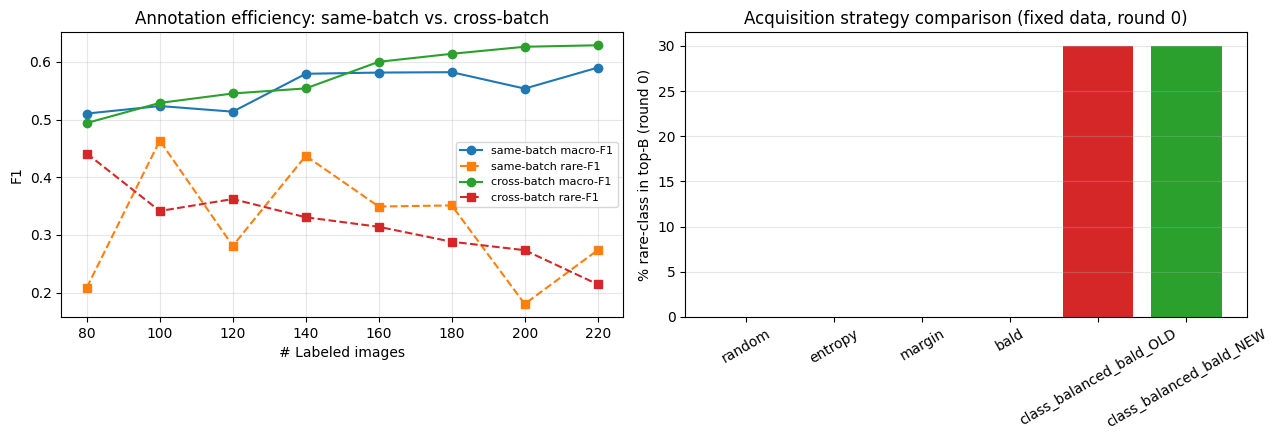

Saved to /content/drive/MyDrive/cse754/outputs/phase7_summary_plots.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for label, log in [('same-batch', results_samebatch), ('cross-batch', results_crossbatch)]:
    n_lab = [r['n_labeled'] for r in log]
    f1 = [r['test']['macro_f1'] for r in log]
    rare_f1 = [r['test']['rare_class_f1'] for r in log]
    axes[0].plot(n_lab, f1, marker='o', label=f'{label} macro-F1')
    axes[0].plot(n_lab, rare_f1, marker='s', linestyle='--', label=f'{label} rare-F1')
axes[0].set_xlabel('# Labeled images'); axes[0].set_ylabel('F1')
axes[0].set_title('Annotation efficiency: same-batch vs. cross-batch')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

names = list(acq_cmp_samebatch.keys())
vals = [acq_cmp_samebatch[n] for n in names]
colors = ['tab:red' if 'OLD' in n else 'tab:green' if 'NEW' in n else 'tab:gray' for n in names]
axes[1].bar(names, vals, color=colors)
axes[1].set_ylabel('% rare-class in top-B (round 0)')
axes[1].set_title('Acquisition strategy comparison (fixed data, round 0)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plot_path = os.path.join(OUT_DIR, 'phase7_summary_plots.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print('Saved to', plot_path)

## Notes / next steps
- If `class_balanced_bald_NEW`'s bar in Section 11's right-hand plot doesn't clearly beat
  `class_balanced_bald_OLD` and entropy, **report that honestly** — a documented negative result
  (the fix didn't help, here's why we think that is) is a legitimate and gradeable finding, and
  more convincing than silently dropping the comparison.
- Feed `phase7_samebatch/al_results_log.json`, `phase7_crossbatch/al_results_log.json`, and
  `phase7_generalization_gap.json` into **Phase 8** (the consolidated report notebook) along with
  the earlier phases' logs for the final comparison table and plots.
- For a stronger thesis-level (not needed for the course report) version of this: repeat both
  `run_experiment()` calls over 3 seeds and report mean +/- std, since a single seed run cannot
  distinguish a genuine acquisition-function improvement from run-to-run noise, especially at
  n=12-15 rare-class examples.